In [1]:
# Copyright (c) Meta Platforms, Inc. and affiliates. All rights reserved.

# 通过渲染调整网格

本教程展示了如何：
- 从`.obj`文件加载网格和纹理。 
- 通过从多个视点渲染纹理网格来创建合成数据集

- 使用差分轮廓渲染将网格拟合到观察到的合成图像
- 使用差分纹理渲染来调整网格及其纹理

## 0.安装和导入模块

导入需要的模块，主要是 `torch`、`matplotlib`、`pytorch3d`:

In [2]:
import os
import torch # 模型训练
import matplotlib.pyplot as plt # 可视化

from pytorch3d.utils import ico_sphere
import numpy as np # python数值计算库库
from tqdm.notebook import tqdm

# Util function for loading meshes
from pytorch3d.io import load_objs_as_meshes, save_obj # 加载模型

from pytorch3d.loss import ( # 拟合loss
    chamfer_distance, 
    mesh_edge_loss, 
    mesh_laplacian_smoothing, 
    mesh_normal_consistency,
)

# Data structures and functions for rendering
from pytorch3d.structures import Meshes
from pytorch3d.renderer import (
    look_at_view_transform,
    FoVPerspectiveCameras, 
    PointLights, 
    DirectionalLights, 
    Materials, 
    RasterizationSettings, 
    MeshRenderer, 
    MeshRasterizer,  
    SoftPhongShader,
    SoftSilhouetteShader,
    SoftPhongShader,
    TexturesVertex
)

import sys
import os


需要从本地读取的代码文件，已更改为从p3d_utils导入，不需要重新下载

In [4]:
# !wget https://raw.githubusercontent.com/facebookresearch/pytorch3d/main/docs/tutorials/utils/plot_image_grid.py
from p3d_utils.plot_image_grid import image_grid

### 1.加载网格和纹理文件

加载一个`.obj`文件及其关联的`.mtl`文件，并创建一个**纹理**和**网格**对象。 

**Meshes**是PyTorch3D中提供的一种独特的数据结构，用于处理不同大小的网格批。 

**TexturesVertex**是一种辅助数据结构，用于存储有关网格的顶点rgb纹理信息。 

**Meshes**有几个类方法，在整个渲染管道中使用。

需要从本地读取的模型文件，已加载到本地，不需要重新下载

In [5]:
# !mkdir -p data/cow_mesh
# !wget -P data/cow_mesh https://dl.fbaipublicfiles.com/pytorch3d/data/cow_mesh/cow.obj
# !wget -P data/cow_mesh https://dl.fbaipublicfiles.com/pytorch3d/data/cow_mesh/cow.mtl
# !wget -P data/cow_mesh https://dl.fbaipublicfiles.com/pytorch3d/data/cow_mesh/cow_texture.png

在本次实验中，我们的目标是将初始的球体不断调整，最终优化为所需要重建的模型。  
由于初始球体中心为原点、半径为1，我们需要先把模型中心调整到原点、尺寸也调整为与初始球体，降低优化难度。

In [8]:
# 检查当前运行的设备，gpu(cuda)或cpu
if torch.cuda.is_available():
    device = torch.device("cuda:0")
    torch.cuda.set_device(device)
else:
    device = torch.device("cpu")
print(device)

# 设置数据的路径
DATA_DIR = "./data"
obj_filename = os.path.join(DATA_DIR, "cow_mesh/cow.obj")
os.makedirs("./predicts", exist_ok=True)

# 加载模型文件，mtl材质和png纹理在函数内部自动加载
print(os.path.abspath(obj_filename))
mesh = load_objs_as_meshes([obj_filename], device=device)

# 我们缩放归一化并居中目标网格，以适应以（0,0,0）为中心的半径为1的球体。
# 此处的（scale，center）在重建完成后也会使用，用于将基于球体重建后的网格，恢复其原始中心和比例。
# 请注意，对目标网格进行归一化可以加快优化速度，但不是必需的！
verts = mesh.verts_packed()
N = verts.shape[0]
center = verts.mean(0)
scale = max((verts - center).abs().max(0)[0])
mesh.offset_verts_(-center)
mesh.scale_verts_((1.0 / float(scale)));

cpu
/Users/yangbowen/Desktop/本科/大二/大二下课程/计算机图形学/2025.5.15计算机图形学/CG_E7_data/tutorials/data/cow_mesh/cow.obj


## 2.数据集创建

我们对模型在多个视点进行采样，从不同相机位置渲染模型，得到多视角图像的合成数据集。
在我们创建的渲染器中，着色器对纹理贴图进行插值，得到更精细的颜色。  

In [9]:
# 渲染网格的不同视点的数量，可修改。
num_views = 20

# 获取一组视角。 
elev = torch.linspace(0, 360, num_views)
azim = torch.linspace(-180, 180, num_views) 

# 在物体前方放置一个点光源。如上所述，奶牛的正面朝向-z方向。
lights = PointLights(device=device, location=[[0.0, 0.0, -3.0]])

# Initialize an OpenGL perspective camera that represents a batch of different 
# viewing angles. All the cameras helper methods support mixed type inputs and 
# broadcasting. So we can view the camera from the a distance of dist=2.7, and 
# then specify elevation and azimuth angles for each viewpoint as tensors. 
# 初始化一个代表一批不同视角的OpenGL透视相机。所有摄像头辅助方法都支持混合类型输入和广播。
# 因此，我们可以从dist=2.7的距离观察相机，然后将每个视点的仰角和方位角指定为张量。
R, T = look_at_view_transform(dist=2.7, elev=elev, azim=azim)
cameras = FoVPerspectiveCameras(device=device, R=R, T=T)

# We arbitrarily choose one particular view that will be used to visualize 
# results
# 我们任意选择一个特定的视图来可视化结果
camera = FoVPerspectiveCameras(device=device, R=R[None, 1, ...], 
                                  T=T[None, 1, ...]) 

# 定义光栅化和着色的设置。在这里，我们将输出图像的大小设置为128X128。
# 由于我们仅出于可视化目的渲染图像，因此我们将设置faces_per_pixel=1和blur_radius=0.0。
# 有关这些参数的说明，请参阅rasteriate_meshes.py。
# 我们还将bin_size和max_faces_per_bin保留为默认值None，这将使用启发式方法设置它们的值，并确保使用更快的粗到细光栅化方法。
# 请参阅docs/notes/renderer.md，了解朴素光栅化和粗到细光栅化之间的区别。
raster_settings = RasterizationSettings(
    image_size=128, 
    blur_radius=0.0, 
    faces_per_pixel=1, 
)

# sample from a texture image and apply the Phong lighting model
# 通过组合光栅化器和着色器来创建Phong渲染器。
# 纹理Phong着色器将插值每个顶点的纹理uv坐标，从纹理图像中采样并应用Phong照明模型
renderer = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=camera, 
        raster_settings=raster_settings
    ),
    shader=SoftPhongShader(
        device=device, 
        cameras=camera,
        lights=lights
    )
)

# 通过重复奶牛网格和相关纹理来创建一批网格。
# Meshes有一个有用的“扩展”方法，可以让我们很容易地做到这一点。这也扩展了纹理。
meshes = mesh.extend(num_views)

# 从每个视角渲染奶牛网格
target_images = renderer(meshes, cameras=cameras, lights=lights)

# 我们的多视图奶牛数据集将由这两个张量列表表示，每个张量的长度为num_views。
target_rgb = [target_images[i, ..., :3] for i in range(num_views)]
target_cameras = [FoVPerspectiveCameras(device=device, R=R[None, i, ...], 
                                           T=T[None, i, ...]) for i in range(num_views)]

渲染得到的数据集中，共20张图像，为同一模型的不同视角渲染图像；该数据集即为我们后续重建时的输入。  
可视化数据集：

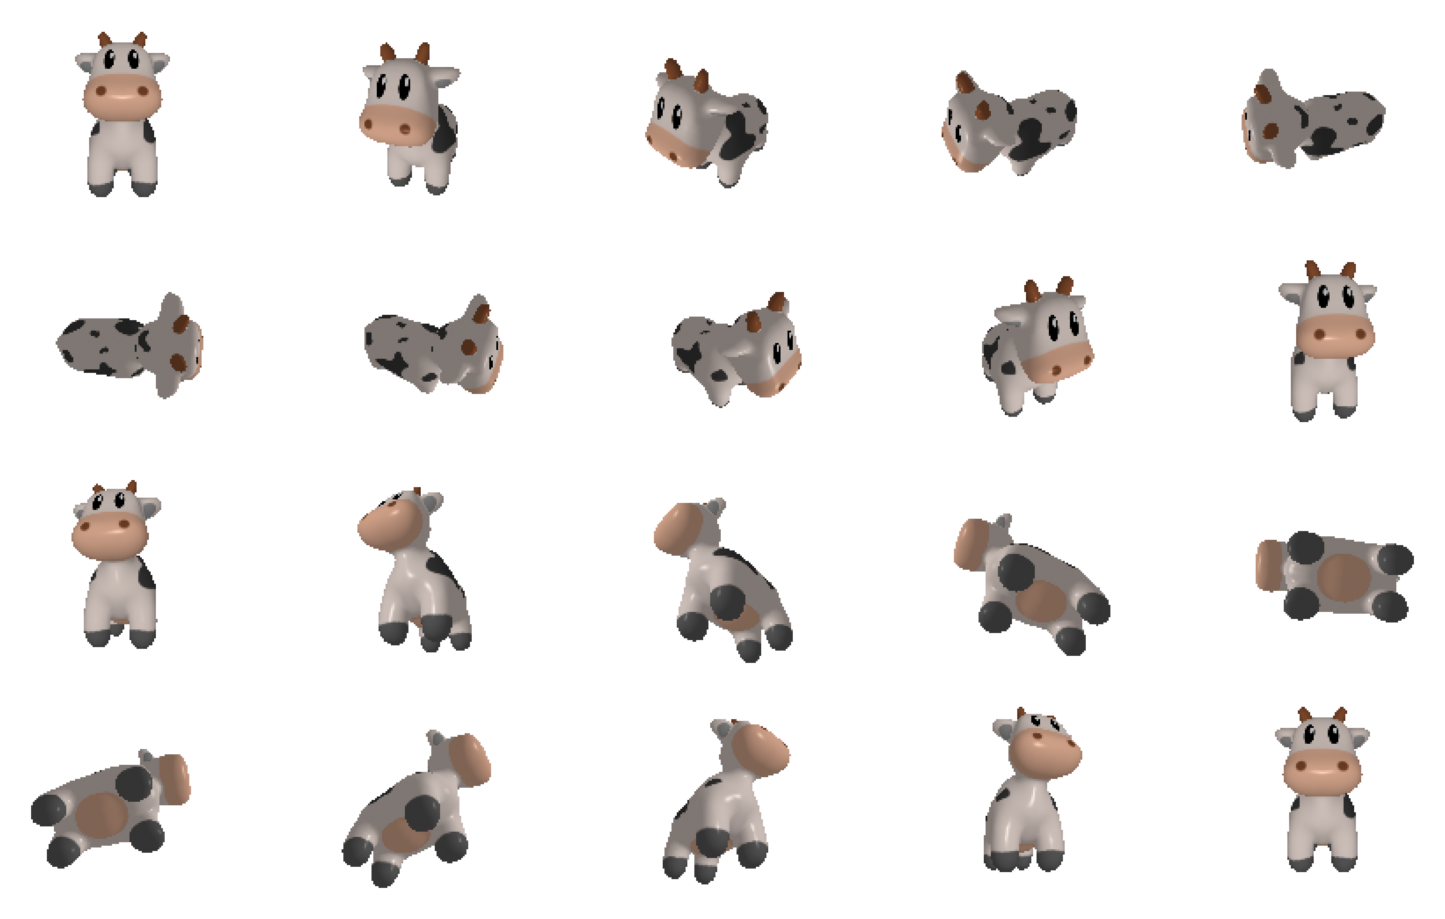

In [10]:
# RGB图像
image_grid(target_images.cpu().numpy(), rows=4, cols=5, rgb=True)
plt.show()

在本教程的后面，我们将为渲染的RGB图像以及仅含模型轮廓的图像拟合网格。  
对于后一种情况，我们将渲染轮廓图像的数据集。

PyTorch3D中的大多数着色器将输出alpha通道（透明通道）以及RGB图像；作为RGBA图像中的第四个通道，alpha通道对每个像素属于对象前景的概率进行编码。  
我们构造了一个软轮廓着色器来渲染这个alpha通道。

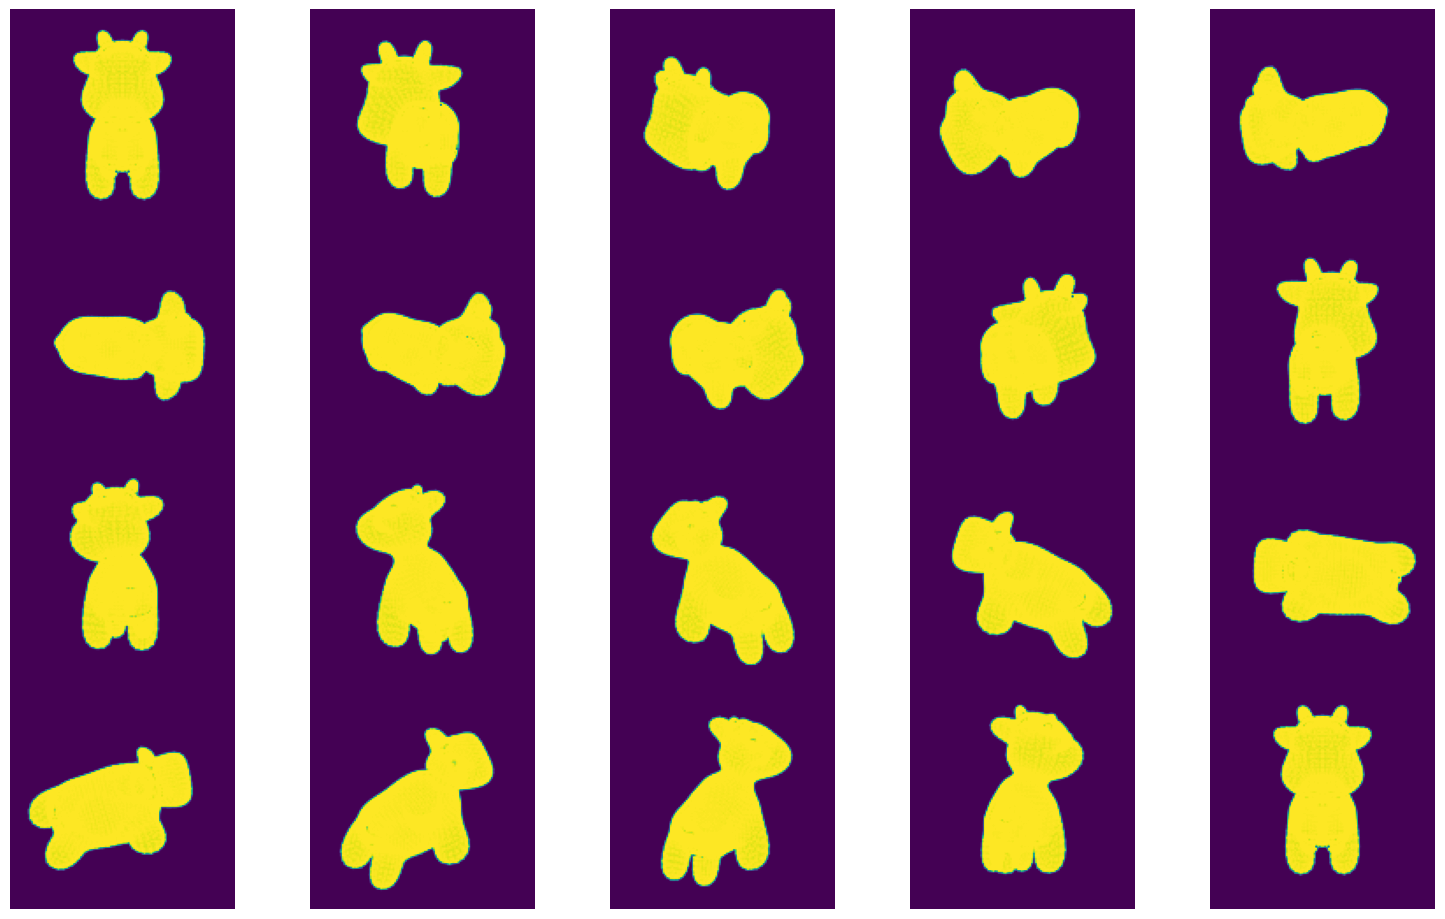

In [11]:
# 轮廓渲染的光栅化设置
sigma = 1e-4
raster_settings_silhouette = RasterizationSettings(
    image_size=128, 
    blur_radius=np.log(1. / 1e-4 - 1.)*sigma, 
    faces_per_pixel=50, 
)

# 轮廓渲染器
renderer_silhouette = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=camera, 
        raster_settings=raster_settings_silhouette
    ),
    shader=SoftSilhouetteShader()
)

# 渲染轮廓图像。渲染输出的第三个通道是alpha/轮廓通道
silhouette_images = renderer_silhouette(meshes, cameras=cameras, lights=lights)
target_silhouette = [silhouette_images[i, ..., 3] for i in range(num_views)]

# 可视化轮廓图像
image_grid(silhouette_images.cpu().numpy(), rows=4, cols=5, rgb=False)
plt.show()

## 3.网格预测的辅助函数
在上一节中，我们创建了一个奶牛多个视点的图像数据集。在本节中，我们通过观察这些目标图像来预测网格，而不需要了解地面真实奶牛网格。我们假设我们知道摄像头和照明的位置。

我们首先定义一些辅助函数来可视化网格预测的结果：

In [12]:
# 显示将渲染的预测网格与地面真实网格进行比较的可视化
def visualize_prediction(predicted_mesh, renderer=renderer_silhouette, 
                         target_image=target_rgb[1], title='', 
                         silhouette=False):
    inds = 3 if silhouette else range(3)
    with torch.no_grad():
        predicted_images = renderer(predicted_mesh)
    plt.figure(figsize=(20, 10))
    plt.subplot(1, 2, 1)
    plt.imshow(predicted_images[0, ..., inds].cpu().detach().numpy())

    plt.subplot(1, 2, 2)
    plt.imshow(target_image.cpu().detach().numpy())
    plt.title(title)
    plt.axis("off")

# 绘制损失作为优化迭代的函数
def plot_losses(losses):
    fig = plt.figure(figsize=(13, 5))
    ax = fig.gca()
    for k, l in losses.items():
        ax.plot(l['values'], label=k + " loss")
    ax.legend(fontsize="16")
    ax.set_xlabel("Iteration", fontsize="16")
    ax.set_ylabel("Loss", fontsize="16")
    ax.set_title("Loss vs iterations", fontsize="16")

从球面网格开始，我们将学习每个顶点的偏移，以便在每个优化步骤中预测的网格轮廓与目标轮廓图像更相似。我们首先加载初始球体网格：

In [13]:
# 我们将源形状初始化为半径为1的球体。  
src_mesh = ico_sphere(4, device)

我们创建了一个新的可微分渲染器来渲染预测网格的轮廓：

我们初始化设置、损失和优化器，这些将用于迭代地将我们的网格拟合到目标轮廓：

In [14]:
# 使网格形状平滑/规则化的loss
def update_mesh_shape_prior_losses(mesh, loss):
    # and (b) the edge length of the predicted mesh
    loss["edge"] = mesh_edge_loss(mesh)
    
    # mesh normal consistency
    loss["normal"] = mesh_normal_consistency(mesh)
    
    # mesh laplacian smoothing
    loss["laplacian"] = mesh_laplacian_smoothing(mesh, method="uniform")

我们编写一个优化循环，迭代地将预测网格从球体网格细化为与目标图像轮廓相匹配的网格：

## 4.通过纹理渲染进行网格和纹理预测
如果我们根据预测的渲染RGB图像与目标图像的比较添加额外的损失，我们可以预测网格及其纹理。如前所述，我们从球体网格开始。我们学习球体网格中每个顶点的平移偏移和RGB纹理颜色。由于我们的损失是基于渲染的RGB像素值，而不仅仅是轮廓，因此我们使用**SoftPhongShader**而不是**SoftSilhouetteShader**。

In [15]:
# 可微分渲染的光栅化设置，其中blur_radius初始化基于ICCV 2019, Liu et al,
# “Soft Rasterizer: A Differentiable Renderer for Image-based 3D Reasoning”，
sigma = 1e-4
raster_settings_soft = RasterizationSettings(
    image_size=128, 
    blur_radius=np.log(1. / 1e-4 - 1.)*sigma, 
    faces_per_pixel=50, 
    perspective_correct=False, 
)

# 可微分软渲染器，使用各顶点RGB颜色表示纹理
renderer_textured = MeshRenderer(
    rasterizer=MeshRasterizer(
        cameras=camera, 
        raster_settings=raster_settings_soft
    ),
    shader=SoftPhongShader(device=device, 
        cameras=camera,
        lights=lights)
)

我们初始化设置、损失和优化器，这些将用于迭代地将我们的网格拟合到目标RGB图像：

In [16]:
# 每次SGD迭代中要优化的视图数量
num_views_per_iteration = 2
# 优化步骤数
Niter = 300 # 教程结果是设置Niter=300得到的
# loss的绘制周期
plot_period = 50

# Optimize using rendered RGB image loss, rendered silhouette image loss, mesh 
# edge loss, mesh normal consistency, and mesh laplacian smoothing
# 使用渲染轮廓图像损失、网格边缘损失、网格法线一致性和网格拉普拉斯平滑进行优化
losses = {"rgb": {"weight": 1.0, "values": []},
          "silhouette": {"weight": 1.0, "values": []},
          "edge": {"weight": 1.0, "values": []},
          "normal": {"weight": 0.01, "values": []},
          "laplacian": {"weight": 1.0, "values": []},
         }

# 我们将学习通过偏移源网格的顶点来变形源网格。
# 变形参数的形状等于src_mesh中的顶点总数
verts_shape = src_mesh.verts_packed().shape
deform_verts = torch.full(verts_shape, 0.0, device=device, requires_grad=True)

# 我们还将学习定义网格纹理的球体网格的顶点颜色
sphere_verts_rgb = torch.full([1, verts_shape[0], 3], 0.5, device=device, requires_grad=True)

# 优化器
optimizer = torch.optim.SGD([deform_verts, sphere_verts_rgb], lr=1.0, momentum=0.9)

我们编写一个优化循环，迭代地将预测的网格及其顶点颜色从球体网格细化为与目标图像匹配的网格：

In [7]:

loop = tqdm(range(Niter))

for i in loop:
    # 初始化优化器
    optimizer.zero_grad()
    
    # 通过更新顶点位置，来让网格变形
    new_src_mesh = src_mesh.offset_verts(deform_verts)
    
    # 添加顶点颜色，以对网格进行纹理处理
    new_src_mesh.textures = TexturesVertex(verts_features=sphere_verts_rgb) 
    
    # loss：使网格形状平滑/规则化的损失
    loss = {k: torch.tensor(0.0, device=device) for k in losses}
    update_mesh_shape_prior_losses(new_src_mesh, loss)
    
    # 在每次迭代中随机选择两个视图进行优化。
    # 与仅使用一个视图相比，这有助于解决更新网格形状与更新网格纹理之间的歧义
    for j in np.random.permutation(num_views).tolist()[:num_views_per_iteration]:
        images_predicted = renderer_textured(new_src_mesh, cameras=target_cameras[j], lights=lights)

        # loss：从我们的数据集中预测的轮廓和目标轮廓之间的平方L2距离
        predicted_silhouette = images_predicted[..., 3]
        loss_silhouette = ((predicted_silhouette - target_silhouette[j]) ** 2).mean()
        loss["silhouette"] += loss_silhouette / num_views_per_iteration
        
        # loss：预测的RGB图像和我们数据集中的目标图像之间的平方L2距离
        predicted_rgb = images_predicted[..., :3]
        loss_rgb = ((predicted_rgb - target_rgb[j]) ** 2).mean()
        loss["rgb"] += loss_rgb / num_views_per_iteration
    
    # loss：损失加权和
    sum_loss = torch.tensor(0.0, device=device)
    for k, l in loss.items():
        sum_loss += l * losses[k]["weight"]
        losses[k]["values"].append(float(l.detach().cpu()))
    
    # 输出总loss
    loop.set_description("total_loss = %.6f" % sum_loss)
    
    # 绘制mesh
    if i % plot_period == 0:
        visualize_prediction(new_src_mesh, renderer=renderer_textured, title="iter: %d" % i, silhouette=False)
        # 调用save_obj存储预测的模型结果
        predict_verts, predict_faces = new_src_mesh.get_mesh_verts_faces(0)
        predict_verts = predict_verts * scale + center
        predict_obj_path = os.path.join('./predicts', f'model_{i}.obj')
        save_obj(predict_obj_path, predict_verts, predict_faces)
 
    # 优化步骤
    sum_loss.backward()
    optimizer.step()

NameError: name 'Niter' is not defined

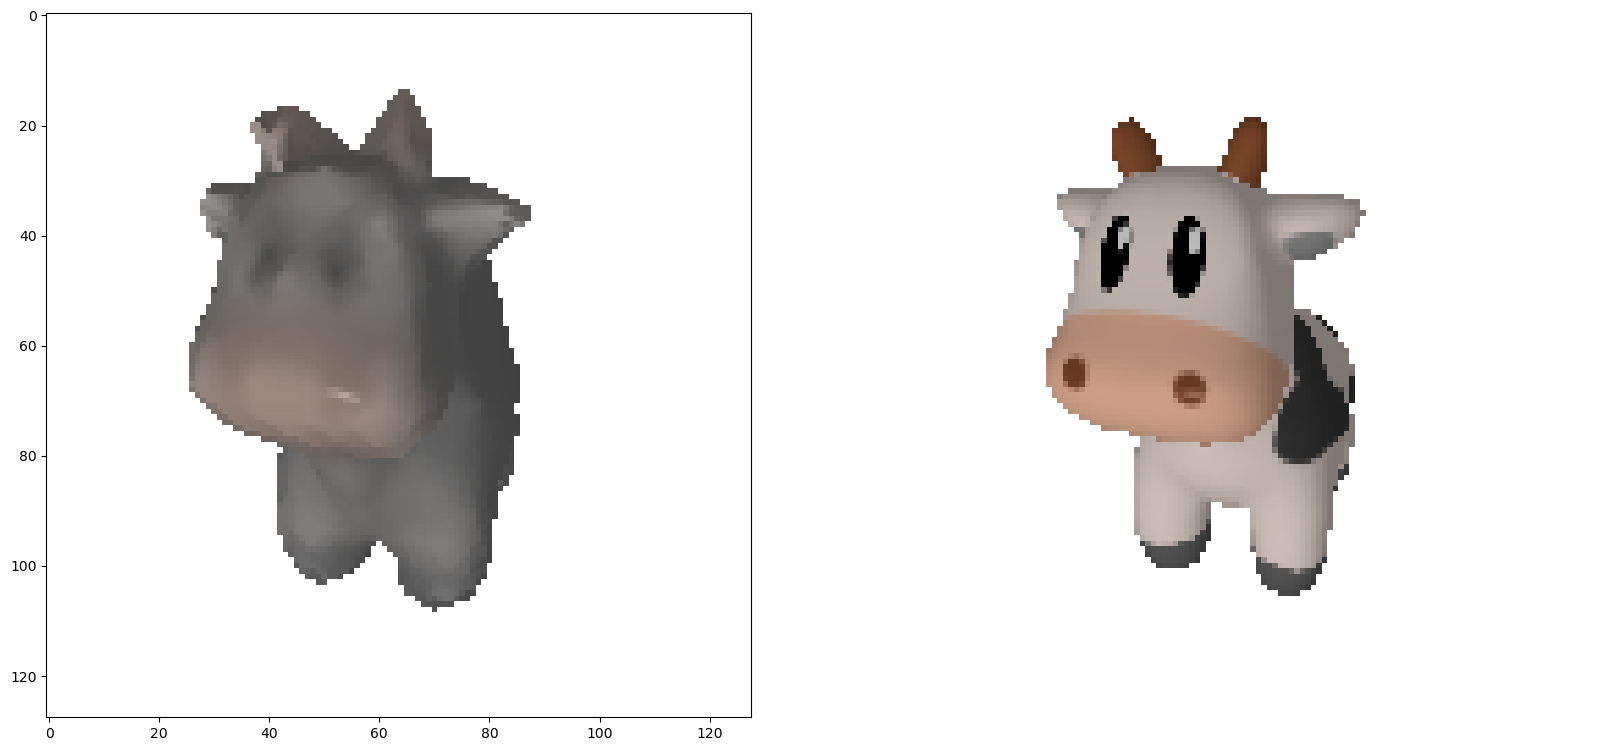

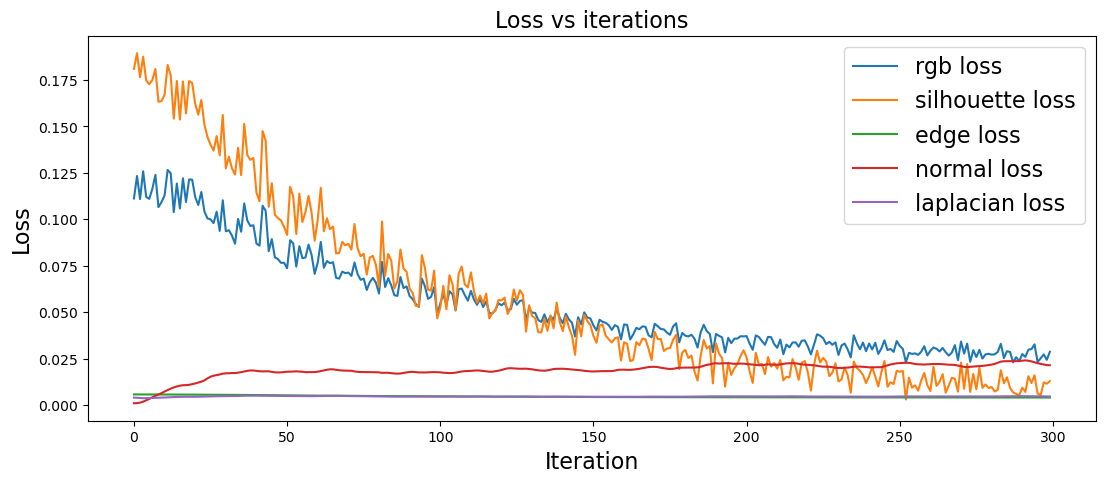

In [15]:
visualize_prediction(new_src_mesh, renderer=renderer_textured, silhouette=False)
plot_losses(losses)

## 5. 保存预测的网格

In [16]:
# 获取最终预测网格模型的顶点（verts）和三角片索引（faces）
final_verts, final_faces = new_src_mesh.get_mesh_verts_faces(0)

# 缩放为原始模型大小，修正位置
final_verts = final_verts * scale + center

# 调用save_obj存储预测的模型结果
final_obj = os.path.join('./predicts', 'model_final.obj')
save_obj(final_obj, final_verts, final_faces)

## 6.结论
在本教程中，我们学习了如何从obj文件加载纹理网格，通过从多个视点渲染网格来创建合成数据集。我们展示了如何建立一个优化循环，根据渲染的轮廓损失将网格拟合到观察到的数据集图像中。然后，我们基于渲染的RGB图像，通过额外的损失来增强这个优化循环，这使我们能够预测网格及其纹理。